#### Set up environment and import required libraries

In [13]:
import sys
import numpy as np
import jax
import os
import time

cpu = True
if cpu:
    N = 32
    os.environ['XLA_FLAGS'] = f'--xla_force_host_platform_device_count={N}'

# Import all required libraries
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import pandas as pd 
import jax.numpy as jnp
import copy
import optax
import scipy.io as sio
from scipy.io import loadmat
import equinox as eqx
from typing import Tuple
from itertools import product
import joblib
from joblib import Parallel, delayed
from contextlib import contextmanager
from tqdm.auto import tqdm

# Jax enable x64
jax.config.update("jax_enable_x64", True)

# Import from tvboptim
from tvboptim.types import Parameter, BoundedParameter
from tvboptim.types.stateutils import show_parameters
from tvboptim.utils import set_cache_path, cache
from tvboptim.optim.optax import OptaxOptimizer
from tvboptim.optim.callbacks import MultiCallback, DefaultPrintCallback, SavingLossCallback

# Network dynamics imports
from tvboptim.experimental.network_dynamics import Network, solve, prepare
from tvboptim.experimental.network_dynamics.dynamics.tvb import ReducedWongWang
from tvboptim.experimental.network_dynamics.coupling.base import InstantaneousCoupling
from tvboptim.experimental.network_dynamics.coupling import LinearCoupling, FastLinearCoupling
from tvboptim.experimental.network_dynamics.graph import DenseDelayGraph, DenseGraph
from tvboptim.experimental.network_dynamics.solvers import Heun, BoundedSolver
from tvboptim.experimental.network_dynamics.noise import AdditiveNoise
from tvboptim.data import load_structural_connectivity, load_functional_connectivity
from tvboptim.experimental.network_dynamics.dynamics.base import AbstractDynamics
from tvboptim.experimental.network_dynamics.core.bunch import Bunch

# BOLD monitoring
from tvboptim.observations.tvb_monitors.bold import Bold

# Observation functions
from tvboptim.observations.observation import compute_fc, fc_corr, rmse

# Caching utilities
from tvboptim.utils import set_cache_path, cache

# Set cache path for tvboptim
set_cache_path("ei_tuning")

Cache stored here: c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\cache\ei_tuning


'c:\\Users\\Bruna\\Documents\\Cogmaster\\M2\\Stage\\scripts\\TVBOptim\\cache\\ei_tuning'

#### Set up data for optimization 

In [14]:
# Load FC0 matrix for all participants and conditions. shape -> (n_participants, n_conditions, n_regions, n_regions)
fc0 = np.load('FC0_empirical.npy')
# Choose one participant and condition to visualize
conditions = {0: 'CTR', 1: 'SCZ'}
participant_idx = 0
condition_idx = 0
# Extract the FC0 matrix for the chosen participant and condition
fc0_test = fc0[participant_idx, condition_idx, :, :]
# Set extracted FC as target for optimization
fc_target = fc0_test

## Load SC matrix and tract lenghts
# Weights
SCR = sio.loadmat('SC_EnigmadK68.mat')['matrix']
weights = SCR / np.max(SCR)
n_nodes = weights.shape[0]

# Delays
lengths = pd.read_csv('tract_lengths.csv')
speed = 3.0
delays = lengths / speed

# Load empirical functional connectivity as optimization target
fc_target = fc0_test
# Set target FC diagonal to zero to ignore diagonal (self-connections) during loss calculation
fc_target = jnp.fill_diagonal(fc_target, 0.0, inplace=False)

# Load region labels and coordinates
df = pd.read_csv(
    'centers.txt',
    sep='\t',
    header=None,
    dtype={1: float, 2: float, 3: float},
    names=['label', 'x', 'y', 'z']
)

labels = df['label'].tolist()
coords = df[['x','y','z']].values

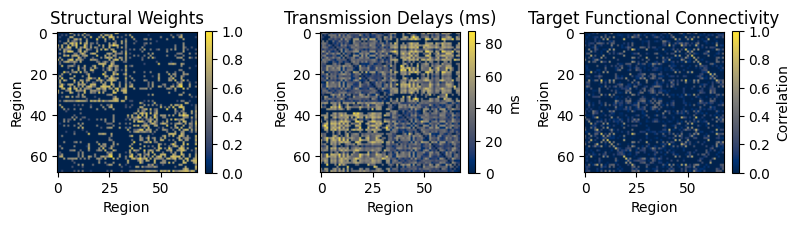

In [15]:
# Define consistent color palette derived from cividis
import matplotlib.colors as mcolors
cividis_cmap = plt.cm.cividis
cividis_colors = cividis_cmap(np.linspace(0, 1, 256))
accent_blue = cividis_cmap(0.3)  # Dark blue from cividis
accent_gold = cividis_cmap(0.85)  # Gold/yellow from cividis
accent_mid = cividis_cmap(0.6)   # Mid-tone

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8.1, 4))

# Structural weights - use cividis
im1 = ax1.imshow(weights, cmap='cividis', vmin=0, vmax=1)
ax1.set_title('Structural Weights')
ax1.set_xlabel('Region')
ax1.set_ylabel('Region')
plt.colorbar(im1, ax=ax1, fraction=0.046)

# Delays - use cividis
im2 = ax2.imshow(delays, cmap='cividis')
ax2.set_title('Transmission Delays (ms)')
ax2.set_xlabel('Region')
ax2.set_ylabel('Region')
plt.colorbar(im2, ax=ax2, fraction=0.046, label='ms')

# Target FC - use cividis
im3 = ax3.imshow(fc_target, vmin=0, vmax=1.0, cmap='cividis')
ax3.set_title('Target Functional Connectivity')
ax3.set_xlabel('Region')
ax3.set_ylabel('Region')
plt.colorbar(im3, ax=ax3, label='Correlation', fraction=0.046)

plt.tight_layout()
plt.show()

#### Define the model to optimize

In [16]:
class ReducedWongWangEIB(AbstractDynamics):
    """Two-population Reduced Wong-Wang model with E-I balance support"""

    STATE_NAMES = ('S_e', 'S_i')
    INITIAL_STATE = (0.001, 0.001)
    AUXILIARY_NAMES = ('H_e', 'H_i')
    g_prop = 0  # awake

    DEFAULT_PARAMS = Bunch(
        # Excitatory population parameters
        a_e=310.0,         # Input gain parameter
        b_e=125.0,         # Input shift parameter [Hz]
        d_e=0.160,         # Input scaling parameter [s]
        gamma_e=0.641/1000,  # Kinetic parameter
        tau_e=100.0,       # NMDA decay time constant [ms]
        w_p   = 1.4 * (1 - 0.2*g_prop),           # Excitatory recurrence weight
        W_e=1.0,           # External input scaling weight

        # Inhibitory population parameters
        a_i=615.0,         # Input gain parameter
        b_i=177.0,         # Input shift parameter [Hz]
        d_i=0.087,         # Input scaling parameter [s]
        gamma_i=1.0/1000,  # Kinetic parameter
        tau_i = 10  * (1 + 0.8*g_prop),        # NMDA decay time constant [ms]
        W_i=0.7,           # External input scaling weight

        # Synaptic weights
        J_N=0.15,          # NMDA current [nA]
        J_i   = 1.0 * (1 + 0.6*g_prop),          # Inhibitory synaptic weight

        # External inputs
        I_o=0.382,         # Background input current
        I_ext=0.0,         # External stimulation current

        # Coupling parameters
        lamda=1.0,         # Lambda: inhibitory coupling scaling

    )

# Primary GABA effect
#J_i = 1.0 → 1.4
# Slower inhibition
#tau_i = 10.0 → 18.0
# Slightly reduced excitation
#w_p = 1.4 → 1.2

    COUPLING_INPUTS = {
        'coupling': 2,  # Long-range excitation and Feedforward inhibition
    }

    def dynamics(
        self,
        t: float,
        state: jnp.ndarray,
        params: Bunch,
        coupling: Bunch,
        external: Bunch
    ) -> Tuple[jnp.ndarray, jnp.ndarray]:
        """Compute two-population Wong-Wang dynamics with dual coupling."""

        # Unpack state variables
        S_e = state[0]  # Excitatory synaptic gating
        S_i = state[1]  # Inhibitory synaptic gating

        # Unpack coupling inputs
        c_lre = params.J_N * coupling.coupling[0]  # Long-range excitation
        c_ffi = params.J_N * coupling.coupling[1]  # Feedforward inhibition

        # Excitatory population input
        J_N_S_e = params.J_N * S_e
        x_e_pre = (params.w_p * J_N_S_e - params.J_i * S_i +
                   params.W_e * params.I_o + c_lre + params.I_ext)

        # Excitatory transfer function
        x_e = params.a_e * x_e_pre - params.b_e
        H_e = x_e / (1.0 - jnp.exp(-params.d_e * x_e))

        # Excitatory dynamics
        dS_e_dt = -(S_e / params.tau_e) + (1.0 - S_e) * H_e * params.gamma_e

        # Inhibitory population input
        x_i_pre = J_N_S_e - S_i + params.W_i * params.I_o + params.lamda * c_ffi

        # Inhibitory transfer function
        x_i = params.a_i * x_i_pre - params.b_i
        H_i = x_i / (1.0 - jnp.exp(-params.d_i * x_i))

        # Inhibitory dynamics
        dS_i_dt = -(S_i / params.tau_i) + H_i * params.gamma_i

        # Package results
        derivatives = jnp.array([dS_e_dt, dS_i_dt])
        auxiliaries = jnp.array([H_e, H_i])

        return derivatives, auxiliaries
    
class EIBLinearCoupling(InstantaneousCoupling):
    """EIB Linear coupling with separate excitatory and inhibitory weight matrices.

    This coupling produces two outputs:
        c_lre: Long-range excitation (wLRE * S_e)
        c_ffi: Feedforward inhibition (wFFI * S_e)

    Both couplings are driven by the excitatory activity (S_e) from other regions.
    """

    N_OUTPUT_STATES = 2  # Produces two coupling outputs

    DEFAULT_PARAMS = Bunch(
        wLRE = 1.0,  # Long-range excitation weight matrix
        wFFI = 1.0,  # Feedforward inhibition weight matrix
    )

    def pre(
        self,
        incoming_states: jnp.ndarray,
        local_states: jnp.ndarray,
        params: Bunch
    ) -> jnp.ndarray:
        """Pre-synaptic transformation: multiply S_e with wLRE and wFFI."""
        # incoming_states[0] is S_e from all source nodes
        S_e = incoming_states[0]  # [n_target, n_source]
        # Apply weights: element-wise multiply S_e with each weight matrix
        # params.wLRE and params.wFFI have shape [n_nodes, n_nodes]
        c_lre = S_e * params.wLRE  # [n_target, n_source]
        c_ffi = S_e * params.wFFI  # [n_target, n_source]

        # Stack into [2, n_target, n_source]
        return jnp.stack([c_lre, c_ffi], axis=0)

    def post(
        self,
        summed_inputs: jnp.ndarray,
        local_states: jnp.ndarray,
        params: Bunch
    ) -> jnp.ndarray:
        """Post-synaptic transformation: pass through without scaling."""
        return summed_inputs
    
## Building the network model ================================
# Create network components
graph = DenseGraph(weights, region_labels=labels)
dynamics = ReducedWongWangEIB(J_i = jnp.ones((n_nodes)))

# Initialize EIB coupling with dual weight matrices
# wLRE and wFFI start as copies of structural connectivity
coupling = EIBLinearCoupling(incoming_states=["S_e"])

# Set the weight matrices to the proper shape based on structural connectivity
# Both start as scaled versions of structural connectivity
coupling.params.wLRE = jnp.ones((n_nodes, n_nodes)) #+ 0.8*fc_target  # [n_nodes, n_nodes]
coupling.params.wFFI = jnp.ones((n_nodes, n_nodes)) #- 0.8*fc_target  # [n_nodes, n_nodes]

# Small noise to break symmetry
noise = AdditiveNoise(sigma=0.01, apply_to="S_e")

# Assemble the network
network = Network(
    dynamics=dynamics,
    coupling={'coupling': coupling},  # Both use same coupling but produce different outputs
    graph=graph,
    noise=noise
)

print(f"Network created with {n_nodes} nodes")

## Initial simulation ================================
# Prepare simulation: compile model and initialize state
t1 = 330_000  # Simulation duration (ms) - 1 minute for initial transient
dt = 4.0      # Integration timestep (ms) matching original script
solver = BoundedSolver(Heun(), low=0.0, high=1.0)
model, state = prepare(network, solver, t1=t1, dt=dt)

# Run initial transient to reach quasi-stationary state
print("Running initial transient simulation...")
result_init = jax.block_until_ready(model(state))

# Update network with final state as new initial conditions
network.update_history(result_init)

# Prepare for shorter simulations used in EI tuning
bold_TR = 2000.0
model_short, state_short = prepare(network, solver, t1=bold_TR, dt=dt)

print(f"Initial simulation complete. Final S_e mean: {result_init.data[-1, 0, :].mean():.3f}")
print(f"Initial simulation complete. Final S_i mean: {result_init.data[-1, 1, :].mean():.3f}")

## Create BOLD monitor for evaluation ================================
# Create BOLD monitor - we'll monitor S_e (first state variable)
# The BOLD period is bold_TR
bold_monitor = Bold(
    period=bold_TR,           # BOLD sampling period (TR = 2000 ms)
    downsample_period=4.0,  # Intermediate downsampling matches dt
    voi=0,                  # Monitor first state variable (S_e)
    history=result_init     # Use initial state as warm start for BOLD history
)

print("BOLD monitor initialized")

## Utility functions ================================
# Will be populated after initial simulation completes
model_eval, state_eval, _state = None, None, None

def setup_eval_model():
    """Setup evaluation model for FC computation (called after initial simulation)."""
    global model_eval, state_eval, _state
    model_eval, state_eval = prepare(network, Heun(), t1=t1, dt=dt)
    _state = copy.deepcopy(state_eval)

def eval_fc(J_i, wLRE, wFFI):
    """Evaluate FC for given parameters using a long simulation."""
    _state.dynamics.J_i = J_i
    _state.coupling.coupling.wLRE = wLRE
    _state.coupling.coupling.wFFI = wFFI

    # Run simulation
    raw_result = model_eval(_state)

    # Compute BOLD
    bold_signal = bold_monitor(raw_result)

    # Compute FC (skip initial transient)
    fc = compute_fc(bold_signal, skip_t=20)
    return fc

Network created with 68 nodes
Running initial transient simulation...
Initial simulation complete. Final S_e mean: 0.855
Initial simulation complete. Final S_i mean: 0.948
BOLD monitor initialized


In [17]:
## FIC tuning ================================

def FIC_update_rule(J_i, raw_data, eta_fic=0.1, target_fic=0.25):
    """Update J_i using FIC algorithm to maintain E-I balance."""
    # Compute mean activity over the simulation window
    mean_S_i = jnp.mean(raw_data[:, 1], axis=0)  # Mean S_i over time [n_nodes]
    mean_S_e = jnp.mean(raw_data[:, 0], axis=0)  # Mean S_e over time [n_nodes]

    # FIC update rule: increase J_i if E activity is too high
    # When mean_S_e > target_fic, d_J_i is positive, increasing inhibition
    d_J_i = eta_fic * (mean_S_i * mean_S_e - target_fic * mean_S_i)
    J_i_new = J_i + d_J_i

    return J_i_new

print("FIC update function defined")

# FIC tuning parameters
eta_fic = 0.5  # Learning rate for FIC
target_fic = 0.25  # Target excitatory activity level
n_fic_steps = 200  # Number of FIC iterations

FIC update function defined


Gradient-based optimization approach ================================

In [18]:
# Prepare simulation
t1_opt = 330_000 # Simulation duration (ms) 
dt_opt = 4.0
solver_opt = BoundedSolver(Heun(), low=0.0, high=1.0)
model_opt, state_opt = prepare(network, solver_opt, t1=t1_opt, dt=dt_opt)

# Create BOLD monitor
bold_monitor_opt = Bold(
    period=bold_TR,
    downsample_period=4.0,
    voi=0,
    history=result_init
)

print("Optimization model prepared")

# Define loss function for optimization

def loss(state):
    """Combined loss function for FC matching and E-I balance"""
    # Simulate neural dynamics
    ts = model_opt(state)

    # Compute BOLD signal from simulated activity
    bold = bold_monitor_opt(ts)

    # Loss component 1: FC discrepancy with empirical data
    fc_pred = compute_fc(bold, skip_t=4)  # Skip initial transient
    fc_loss = rmse(fc_pred, fc_target)

    # Loss component 2: Feedback inhibition control
    # Penalize deviation from target excitatory activity level
    mean_activity = jnp.mean(ts.data[-500:, 0, :], axis=0)  # Mean S_e over final timesteps
    activity_loss = jnp.mean((mean_activity - target_fic) ** 2)

    # Combined loss (both terms have similar scales)
    return fc_loss + activity_loss

# Evaluate initial loss
initial_loss = loss(state_opt)
print(f"Initial loss: {initial_loss:.4f}")

# Mark parameters for optimization (J_i, wLRE, wFFI) with appropriate constraints
state_opt.dynamics.J_i = Parameter(state_opt.dynamics.J_i)
state_opt.coupling.coupling.wLRE = BoundedParameter(jnp.ones((n_nodes, n_nodes)), low=0.0, high=jnp.inf)
state_opt.coupling.coupling.wFFI = BoundedParameter(jnp.ones((n_nodes, n_nodes)), low=0.0, high=jnp.inf)

# Define gradient optimization function 
@cache("gradient_optimization", redo=True)
def run_gradient_optimization(
    max_steps=70,
    learning_rate= 0.05,
    lr_schedule="constant",
    cosine_alpha=0.0,
    cosine_decay_steps=40,
    verbose=True,
):
    """Run gradient-based optimization with optional LR scheduling.

    Parameters
    ----------
    max_steps : int
        Number of optimization steps.
    learning_rate : float
        Initial learning rate.
    lr_schedule : str
        "constant" or "cosine".
    cosine_alpha : float
        Final LR fraction for cosine decay (0.0 means decays to 0).
    cosine_decay_steps : int or None
        Number of decay steps for cosine schedule. If None, uses max_steps.
    verbose : bool
        Whether to print schedule information.
    """

    # Choose learning rate: fixed scalar or cosine-decay schedule
    if lr_schedule == "cosine":
        decay_steps = max_steps if cosine_decay_steps is None else int(cosine_decay_steps)
        lr = optax.cosine_decay_schedule(
            init_value=learning_rate,
            decay_steps=decay_steps,
            alpha=cosine_alpha,
        )
        if verbose:
            print(
                f"Using cosine LR: init={learning_rate}, decay_steps={decay_steps}, alpha={cosine_alpha}"
            )
    elif lr_schedule == "constant":
        lr = learning_rate
        if verbose:
            print(f"Using constant LR: {learning_rate}")
    else:
        raise ValueError("lr_schedule must be 'constant' or 'cosine'")

    # Create optimizer
    optimizer = OptaxOptimizer(
        loss,
        optax.adamaxw(learning_rate=lr),
        callback=MultiCallback([DefaultPrintCallback(), SavingLossCallback()])
    )

    # Run optimization
    opt_state, opt_fitting_data = optimizer.run(state_opt, max_steps=max_steps)

    return opt_state, opt_fitting_data

#  Setup evaluation model
setup_eval_model()

# Compute FC before gradient descent optimization
print("Computing pre-gradient descent functional connectivity...")
fc_pre_gd = eval_fc(
    state_opt.dynamics.J_i,
    state_opt.coupling.coupling.wLRE,
    state_opt.coupling.coupling.wFFI
)

# Compute quality metrics
fc_corr_pre = fc_corr(fc_pre_gd, fc_target)
fc_rmse_pre = jnp.sqrt(jnp.mean((fc_pre_gd - fc_target)**2))

## Grid search on hyperparameters ================================
@contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()

# Parameter grid
param_grid = {
    "l_r": jnp.linspace(1e-3, 1e-1, 2),
    "steps_grid": jnp.linspace(20, 25, 2, dtype=jnp.int32),
}
trials = [
    (float(lr), int(steps))
    for lr, steps in product(np.array(param_grid["l_r"]), np.array(param_grid["steps_grid"]))
]

def evaluate_trial(lr, steps):
    opt_state, _ = run_gradient_optimization(learning_rate=lr, max_steps=steps)
    fc_opt = eval_fc(
        opt_state.dynamics.J_i,
        opt_state.coupling.coupling.wLRE,
        opt_state.coupling.coupling.wFFI
    )
    corr_val = fc_corr(fc_opt, fc_target)
    loss_val = rmse(fc_opt, fc_target)
    return {
        "l_r": lr,
        "steps": steps,
        "corr": float(jnp.nan_to_num(corr_val, nan=-jnp.inf)),
        "loss": float(jnp.nan_to_num(loss_val, nan=jnp.inf)),
    }

n_cpus = 1 if os.name == "nt" else min(4, os.cpu_count() or 1)

if n_cpus == 1:
    # Reliable progress on Windows/single-core mode
    results = [evaluate_trial(lr, steps) for lr, steps in tqdm(trials, desc="Hyperparam search")]
else:
    # Parallel + tqdm integration
    with tqdm_joblib(tqdm(total=len(trials), desc="Hyperparam search")):
        results = Parallel(n_jobs=n_cpus, backend="loky", batch_size=1)(
            delayed(evaluate_trial)(lr, steps) for lr, steps in trials
        )

results_df = pd.DataFrame(results).sort_values("loss", ascending=True)
best = results_df.iloc[0]
print("Best by RMSE:", best.to_dict())

# Save results
results_df.to_csv("bruna_hyperparam_results.csv", index=False)
best.to_csv("bruna_hyperparam_best.csv", index=False)

Optimization model prepared
Initial loss: 0.6167
Computing pre-gradient descent functional connectivity...


Hyperparam search:   0%|          | 0/4 [00:00<?, ?it/s]

Running computations for gradient_optimization
Using constant LR: 0.001
Step 0: 0.616687
Step 1: 0.615842
Step 2: 0.614993
Step 3: 0.614141
Step 4: 0.613286
Step 5: 0.612426
Step 6: 0.611563
Step 7: 0.610695
Step 8: 0.609823
Step 9: 0.608946
Step 10: 0.608065
Step 11: 0.607178
Step 12: 0.606286
Step 13: 0.605388
Step 14: 0.604484
Step 15: 0.603575
Step 16: 0.602658
Step 17: 0.601736
Step 18: 0.600806
Step 19: 0.599869
Running computations for gradient_optimization
Using constant LR: 0.001
Step 0: 0.616687
Step 1: 0.615842
Step 2: 0.614993
Step 3: 0.614141
Step 4: 0.613286
Step 5: 0.612426
Step 6: 0.611563
Step 7: 0.610695
Step 8: 0.609823
Step 9: 0.608946
Step 10: 0.608065
Step 11: 0.607178
Step 12: 0.606286
Step 13: 0.605388
Step 14: 0.604484
Step 15: 0.603575
Step 16: 0.602658
Step 17: 0.601736
Step 18: 0.600806
Step 19: 0.599869
Step 20: 0.598925
Step 21: 0.597973
Step 22: 0.597013
Step 23: 0.596045
Step 24: 0.595069
Running computations for gradient_optimization
Using constant LR: 